# `Материалы кафедры ММП факультета ВМК МГУ. Введение в глубокое обучение.`

# `Занятие 18. Bert, GPT, T5`

## `Занятие провел: Табаченков Андрей (@taband58)`

## `Материалы составили: Табаченков Андрей (@taband58), Алексеев Илья (@voorhs)`


### `Москва, Весенний семестр 2026`

Источники:
- [Лекция Ильи Алексеева на курсе "Практикум на ЭВМ" кафедры ММП, весна 2024](https://m.youtube.com/watch?v=DDbz_Jm4KJs&list=PLhe7c-LCgl4LrC84sP5IYzC8TCW72AxyB&index=25&pp=iAQB2AbBIQ%3D%3D)
- **BERT**: [Devlin J. et al., 2019](https://arxiv.org/abs/1810.04805), примерно 160,000 цитирований
- **RoBERTa**: [Liu Y. et al., 2019](https://arxiv.org/abs/1907.11692), примерно 26,000 цитирований
- **DistilBERT**: [Sanh V. et al., 2020](https://arxiv.org/abs/1910.01108), примерно 12,000 цитирований
- **GPT2**: [Radford A. et al., 2018](https://papers.baulab.info/papers/Radford-2018.pdf), примерно 24,000 цитирований
- **T5**: [Raffel C. et al., 2020](https://arxiv.org/abs/1910.10683), примерно 31,000 цитирований

Ранее на прошлых парах вы довольно глубоко познакомились с областью Обработки естественного языка. Вам уже известен целый ряд решаемых задач, ровно как и некоторые подоходы к их решению от count-based подходов и методов, основанных на гипотезе дистрибутивности до нейросетевых подходов, включая рекурентные нейронные сети и трансформерные архитектуры, основанные на механизме внимания.

Тем не менее, на реальных практических задачах обучать и применять трансформер с высокими качеством и точностью довольно проблематично. Особенно данная проблема усугубляется с повышением сложности самой задачи NLP, а также при недостатке обучающих данных и/или вычислительных ресурсов. В результате особенно важными становятся выбор архитектуры модели и этап предобучения.

На данной паре мы разберем несколько классических примеров трансформеров: Bert, GPT, T5. Рассмотрим, какие архитектуры используются, как происходил этап их предобучения и как все это помогает повышать качество данных моделей в реальных задачах.

---

# Bert, GPT, T5

## Напоминание

### Механизм внимания и трансформеры

Ранее на прошлой лекции вами был изучен механизм внимания, который в общем виде выглядит вот так:
$$Attention(Q,K,V) = Softmax(QK^T/\sqrt{d})V/$$
Где под $Q$ понимается матрица векторных представлений запросов, $K$ &ndash; ключей, $V$ &ndash; значений, d &ndash; размерность векторных представлений запросов и ключей.
При обучении моделей зачастую требуется ограничить внимание (например, задача next token prediction). Тем самым, возникает маскированное внимание:
$$MaskedAttention(Q,K,V) = Softmax(M + QK^T/\sqrt{d})V/$$
Маска $M$ ограничивает внимание: если ее элемент равен $-\infty$, то в выражении соответствующий вектор-запрос игнорирует соответствующий вектор-ключ при вычислении Softmax.

Двумя основными видами внимания являются само-внимание и кросс-внимание, причем, векторные представления запросов, ключей и значений получаются при помощи применения обучаемых линейных слоев:
$$SelfAttention(E) = Attention(EW_Q, EW_K, EW_V),$$
$$CrossAttention(E, H) = Attention(EW_Q, HW_K, HW_V).$$
В первом случае механизм внимание для каждого вектора-запроса применяется к тому же самому контексту $E$, из которого получен запрос; во втором же случае для каждого вектора запроса из контекста $E$ внимание применяется к иному контексту $H$.

В случае, если мы хотим получать контекстуальные векторные представления (задача кодирования), то в само-внимании достаточно взять нулевую маску $M = 0$, акцентируясь на всем контексте.

Если же мы обучаем модель на задачу предсказания токена по левому контексту (задача декодирования), то нужно использовать маскированное само-внимание, то есть маска имеет блочной вид матрицы, верхний правый блок которой &ndash; верхняя треугольная матрица, заполненная $-∞$, остальные блоки &ndash; нулевые. Тем самым во время обучения для каждого предсказываемого токена в механизме внимания рассматривается только левый контекст. Заметим, при этом, что токены, соответствующие верхнему правому блоку, образуют в совокупности **ответ**, остальные токены &ndash; **запрос**.

Отметим также, что в случае наличия в контексте PAD-токенов, соответствующие им строки и столбцы в масках заполняются $-\infty$.

Также напомним, что для повышения скорости и качества работы, используется много-головочное внимание:
\begin{gather*}
    MultiHeadAttention(Q,K,V) = concat(head_1,...,head_n)W_o,\\
    head_i = Attention(QW_Q^i,KW_K^i,VW_V^i).
\end{gather*}

Каждая из независимых голов внимания отвечает за свою область понимания языка.

Архитектура трансформера:

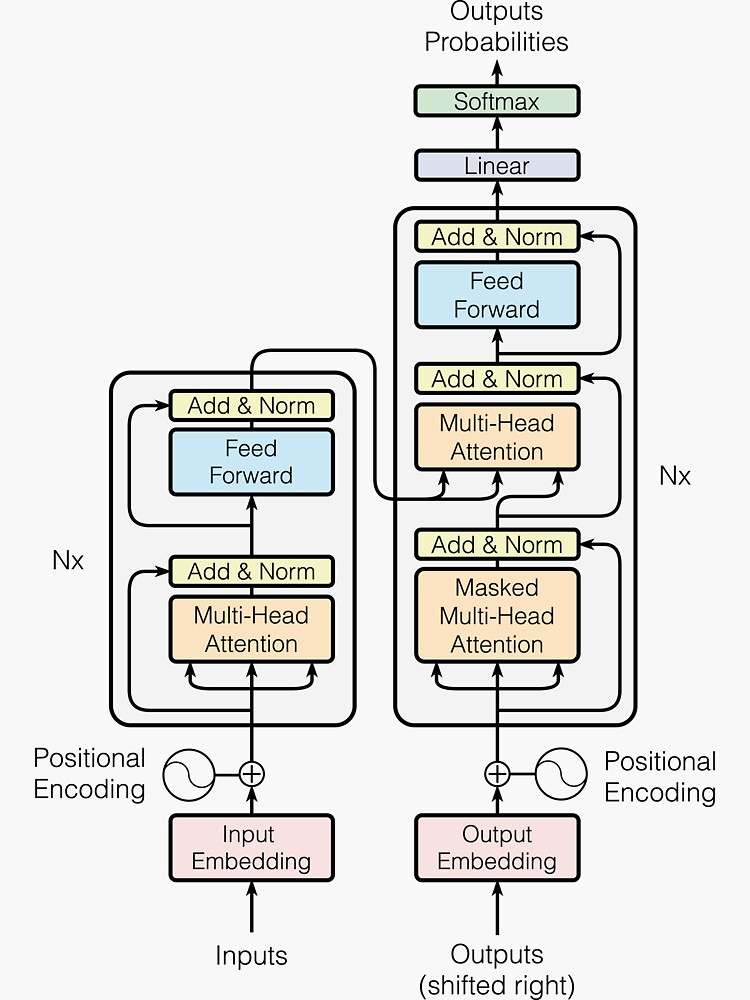

**Attention is all you need**: [Vaswani A. et al., 2017](https://arxiv.org/abs/1706.03762), примерно 240,000 цитирований

Наиболее важные особенности и компоненты:

0. Основные две компоненты &ndash; энкодер и декодер.
1. Обучаемые эмбеддинги токенов словаря токенизатора и позиционные эмбеддинги.
2. Слои само-внимания и кросс-внимания для получения контекстуальных эмбеддингов токенов. Кросс-внимание необходимо для обучения декодировщика генерации токенов относительно контекста запроса.
3. Feed forward слои. Часто содержат 2 линейных слоя и множество обучаемых параметров с информацией о внешнем мире.

ff.drawio.svg

4. Skip-connection + LayerNorm для регуляризации.

### Решаемые задачи

1. Классификация текста. Хотелось бы уметь получать качественные эмбеддинги всего текста, которые далее можно подать на вход классификатору.
2. Классификация токенов. По аналогии с прошлым пунктом, но уже необходимо иметь качественные контекстуальные векторные представления отдельных токенов.
3. Классификация фрагментов в общем случае. Если мы говорим про задачу поиска именованных сущностей и ей подобные, то ее можно решать и другими способами помимо BIO-нотации и классификации токенов. Например, агрегировать эмбеддинги токенов рассматриваемых сущностей для получения эмбеддингов самих фрагментов текста.
4. Causal language modeling. В авторегрессионном режиме на каждом шаге по предыдущим токенам ответа и запросу необходимо генерировать новый очередной токен (по сути, тоже задача классификации). Во время обучения необходимо использовать маскированное внимание (чтобы смотреть только на предыдущие токены).
5. Text-to-text (например, задача машинного перевода). Получение векторных представлений токенов контекста запроса (кодировка), далее в авторегрессионном режиме генерация нового текста. Перед генерацией в модель необходимо подать BOS-токен, который сигнализирует о начале генерируемого текста.
6. Другое. Заметим, что задачи классификации текста, NER, задачи вычисления арифметических выражений и другие можно свести к задаче генерации текста. Достаточно научить языковую модель генерировать ответы в соответствующем формате.
7. Кроме того, перед нами до сих пор стоит общая задача получения качественных векторных представлений токенов, которые, например, можно использовать в кластеризации токенов/текстов/фраз по смыслам.

### Transfer learning

Ранее также рассматривалась проблема, когда требуется обучить модель на небольшом объеме данных, но на довольно сложную задачу. Например, требуется обучить задаче NER. Если обучать модель с нуля, то, вероятнее всего, мы получим неблагоприятный с точки зрения качества исход: не имея качественных контекстуальных векторных представлений токенов, нам при наличии лишь малой обучающей выборки не удастся добиться успеха по классификации токенов.

На помощь приходит **transfer learning**. Предлагается рассматривать обучение моделей на нескольких этапах:
1. Этап предобучения (pretrain). Обучение происходит на общую задачу и на большом объеме данных. Очень часто не требуется наличия разметки данных либо требуется минимальная разметка. Целью является обучение каким-либо общим способностям (например, ResNet после предобучения способен выдавать довольно качественные признаковые описания изображений).
2. Этап дообучения (FineTuning). Вернемся к исходной задаче. Теперь, когда мы имеем предобученную модель с необходимыми нам свойствами, ее можно дообучить на имеющейся малой выборке, достигнув уже достаточно высокого качества.
3. Linear Probing. В идеале, нам достаточно обучить, например, только голову классификации, не размораживая предобученную модель. Если векторные представления объектов достаточно информативны, то в таком случае также можно достичь довольно хорошего качества. На практике последние 2 этапа комбинируют: можно разморозить голову и часть параметров предобученной модели, достигнув качества, сопоставимого со случаем полной разморозки всей модели при сильном ускорении процесса обучения.

## Bert (2019)

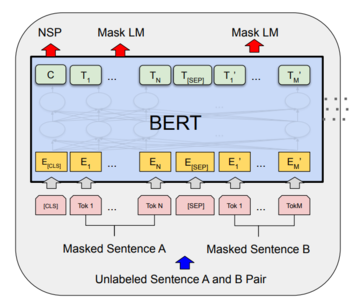

**BERT**: [Devlin J. et al., 2019](https://arxiv.org/abs/1810.04805), примерно 160,000 цитирований

В отличие от общей схемы трансформера в данном случае архитектура модели содержит только энкодер-часть. Предположим, нам хотелось бы, чтобы языковая модель выдавала векторные представления токенов и текста, пригодные для использования в задачах классификации текста и токенов, NER, задаче получения качественных эмбеддингов. Таким образом, хотелось бы наличия у модели двух ключевых свойств:

1. Умение моделировать язык на уровне контекста (гипотеза дистрибутивности).
2. Умение выдавать эмбеддинг текста.

Тем самым мы приходям к стандартным задачам претрейна многих классических моделей на основе архитектуры трансформера:

1. Masked language modeling. Часть токенов исходных текстов заменялась на специальный токен [MASK], с помощью механизма внимания требуется восстановить потерянные токены.
2. Next sentence prediction. Для упорядоченной пары предожений трубется определить, является второе предложение продолжением первого.

При рассмотрении данной и следующих моделей для нас наиболее важным для рассмотрения этапа их предобучения, так как именно он, наряду с архитектурой модели, определяет возможности для дообучения и применения модели в определенных задачах.

**Вопросы:**
1. Как трансформеру решать задачу Masked language modeling?
2. Должен ли эмбеддинг токена для максирования [MASK] быть обучаемым? Если нет, то чему он равен?

1. Masked language modeling. С помощью механизма внимания энкодер восстанаваливал векторные представения соответствующих токенов, подавая их в классификатор по токенам. Тем самым модель обучается моделированию языка и генерации векторных представлений токенов по контексту.
2. Next sentence prediction. Два предложения соединяются в единую последовательность при помощи специального разделительного токена [SEP] (обозначает конец текста/предложения). Начальный [CLS] токен последовательности подается в бинарный классификатор, который предсказывает, является ли второе предложение следующим по смыслу за первым. Тем самым модель обучается моделированию языку на уровне предложений, а векторное представление [CLS] токена может быть использовано как векторное представление текста.

При обучении маски фиксировались для своих текстов до конца обучения. Для токенизации текстов использовалось Byte-pair-encoding на уровне символов.

Предобученный таким образом BERT позволяет решать базовые задачи NLP, перечисленные выше, причем при дообучении на узкий класс задач не требуется размораживать всю модель, а само дообучение не является вычислительно дорогим и долгим по времени. Тем самым, BERT и BERT-подобные языковые модели определенное время достигали SOTA качества во многих задачах NLP.

Отметим также, что обучающие данные для предобучения BERT не требовали ручной разметки, тем самым данное предобучение можно производить на огромных объемах самых разнообразных данных.

**Вопрос:**

3. Как в таком случае применять предобученный BERT в задаче классификации предложений?

### Практика

При обучении и применении моделей на основе Трансформера зачастую используется библиотека HuggingFace (подробное знакомство скоро).

In [ ]:
!pip install transformers datasets evaluate accelerate -q -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 12.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import torch
from torch import nn
import evaluate
from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding
)
from functools import partial

In [ ]:
dataset = load_dataset("imdb")
del dataset['unsupervised']
dataset["train"] = dataset["train"].shuffle(seed=42).select(range(1000))
dataset["test"] = dataset["test"].shuffle(seed=42).select(range(1000))
dataset

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1000
    })
})

In [ ]:
dataset['train'][0]

{'text': 'There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier\'s plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot similarities... The main character is weak and weirdo, but have "clairvoyance". People like to compare, to judge, to evaluate. How about just enjoying? Funny thing too, people writing Fortier looks American but, on the other hand, arguing they prefer American series (!!!). Maybe it\'s the language, or the spirit, but I think this series is more English than American. By the way, the actors are really good and funny. The acting is not superficial at all...',
 'label': 1}

In [ ]:
def preprocess(examples, tokenizer):
    return tokenizer(examples["text"], truncation=True, padding=False)
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
tokenized_dataset = dataset.map(partial(preprocess, tokenizer=tokenizer),
                                batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [ ]:
accuracy = evaluate.load("accuracy")
precision = evaluate.load("precision")
recall = evaluate.load("recall")
f1 = evaluate.load("f1")

In [ ]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {
        'accuracy': accuracy.compute(predictions=predictions, references=labels)['accuracy'],
        'precision': precision.compute(predictions=predictions, references=labels,
                                       average='binary', zero_division=0)['precision'],  # binary для 2 классов
        'recall': recall.compute(predictions=predictions, references=labels,
                                 average='binary', zero_division=0)['recall'],
        'f1': f1.compute(predictions=predictions, references=labels,
                         average='binary')['f1']
    }

In [ ]:
bert = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=2,
    id2label={0: "NEGATIVE", 1: "POSITIVE"},
    label2id={"NEGATIVE": 0, "POSITIVE": 1}
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
bert

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
def parameters_count(model):
  return sum([p.numel() for p in model.parameters()])

In [ ]:
print(f"BERT parameters count: {parameters_count(bert):,}")

BERT parameters count: 109,483,778


In [ ]:
training_args = TrainingArguments(
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    metric_for_best_model="f1",
    report_to="none"
)

trainer = Trainer(
    model=bert,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.521499,0.301917,0.886000,0.874000,0.895492,0.884615
2,0.253601,0.557665,0.810000,0.730650,0.967213,0.832451
3,0.133544,0.382739,0.895000,0.874755,0.915984,0.894895


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=189, training_loss=0.30288155369026953, metrics={'train_runtime': 420.6053, 'train_samples_per_second': 7.133, 'train_steps_per_second': 0.449, 'total_flos': 779622723693120.0, 'train_loss': 0.30288155369026953, 'epoch': 3.0})

In [ ]:
import gc
torch.cuda.empty_cache()
gc.collect()

174

## RoBERTa (2019)

**RoBERTa**: [Liu Y. et al., 2019](https://arxiv.org/abs/1907.11692), примерно 26,000 цитирований

Тем не менее, методология предобучения BERT содержала определенные недостатки, которые стремились устранить авторы RoBERTa. **(?)** Как вы думаете, какие именно?

Рассмотрим, какие нововведения предлагают авторы и с какой целью.
1. Static masking vs dynamic masking. В оригинальном BERT для каждого предложения маски токенов фиксировались до обучения на этапе предобработки данных. Теперь авторы предлагают использовать в обучении последовательность в течении 40 эпох с 10 разными масками, чтобы регуляризовать модель и бороться с предобучением на одни и те же маски.
2. Авторы статьи обнаружили, что обучение на задачу Next Sentence Prediction необязательно. Вместо этого предлагается подавать на вход предложения, сэмплируемые из документов корпуса, причем лучше брать их ровно из 1 документа.
3. Авторы предлагают повышать размеры батчей (с 2000 до 8000), чтобы повысить обобщающую способность модели, а также решить проблему коротких последовательностей (так как мы берем предложения из 1 документа на последовательность, из-за чего общая длина в токенах может быть заметно меньше 512).
4. Также предлагается использовать BPE токенизацию на уровне байтов, а не символов (так как Unicode символы могут занимать довольно обширную часть словаря).

Все эти изменения позволили повысить обобщающую способность итоговой предобученной модели RoBERTa на бенчмарке GLUE. GLUE позволяет оценивать способности модели понимать язык на разных уровнях:
- **CoLa**: бинарная классификация, является ли предложение текстом на английском
- **SST-2**: sentiment analysis
- **MRPC**: классификация пары предожений по семантической эквивалетности
- **QQP**: классификация пары вопросов по эквивалетности
- **STS-B**: задача регрессии, для каждой пары текстов требуется оценить сходство от 1 до 5
- **MNLI**: имея исходное предложение и предложение, содержащее гипотезу, задача состоит в том, чтобы предсказать, вытекает ли исходное предложение из гипотезы (следствие), противоречит ли гипотезе (противоречие) или ни то, ни другое (нейтральное положение)
- **QNLI**: для пары вопрос-ответ требуется предсказать, является ли второй текст ответом на вопрос
- **RTE**: аналогично **MNLI**
- **WNLI**: для текста и выделенного в нем местоимения требуется определить, к какой из данных сущностей местоимение относится

**GLUE**: [Wang A. et al., 2018](https://arxiv.org/abs/1804.07461), примерно 10,000 цитирований

### Практика

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("roberta-base")
tokenized_dataset = dataset.map(partial(preprocess, tokenizer=tokenizer),
                                batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [ ]:
roberta = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base", num_labels=2,
    id2label={0: "NEGATIVE", 1: "POSITIVE"},
    label2id={"NEGATIVE": 0, "POSITIVE": 1}
)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
roberta

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [ ]:
print(f"Roberta parameters count: {parameters_count(roberta):,}")

Roberta parameters count: 124,647,170


In [ ]:
training_args = TrainingArguments(
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    metric_for_best_model="f1",
    report_to="none"
)

trainer = Trainer(
    model=roberta,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.476856,0.310115,0.888000,0.865759,0.911885,0.888224
2,0.266527,0.304485,0.910000,0.871269,0.956967,0.912109
3,0.158138,0.355614,0.911000,0.884393,0.940574,0.911619


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=189, training_loss=0.3005069197801055, metrics={'train_runtime': 419.1104, 'train_samples_per_second': 7.158, 'train_steps_per_second': 0.451, 'total_flos': 776374946603520.0, 'train_loss': 0.3005069197801055, 'epoch': 3.0})

In [ ]:
torch.cuda.empty_cache()
gc.collect()

174

## DistilBERT (2020)

**DistilBERT**: [Sanh V. et al., 2020](https://arxiv.org/abs/1910.01108), примерно 12,000 цитирований

Зачастую требуется найти баланс между качеством модели на решаемой задаче и ее скоростью обучения и инференса. Предположим, у нас есть обученная модель, позволяющая достигать высокого качества на поставленной задаче (teacher), однако в реальном мире хотелось бы применять более компкатную по размерам ее версию (ученик). Обучать с нуля более компактную модель просто напрямую на задачу не является целесообразным, так как мы едва ли сможем достичь такого же качества без необходимого числа параметров и слоев модели. Целью дистиляции знаний является получение более компактной модели (ученика), качество и поведение которой как можно более сопоставимо с исходной (учителем).

В рамках дистиляции помимо обучения на основую задачу ученик также может учиться следующему:
1. Обучение на hard-предсказания учителя &ndash; учимся повторять предсказания модели-учителя.
2. Обучение на soft-предсказания учителя &ndash; учимся предсказывать распределения вероятностей учителя для классов.
3. Обучение на сходство с весами и слоями учителя.

Авторы DistilBERT предлагают сократить число слоев модели вдвое, инициализируя их соответствующими параметрами из BERT, стартуя с приближения к дистиллируемой модели. Далее предобучение производится с функцией потерь из 3 основных компонентов:
1. Функция потерь для задачи MLM. Задача NSP игнорируется по аналогии с RoBERTa.
2. Лосс дистиляции $L_{ce} = -\sum_i t_ilog(s_i)$, где $t_i, s_i$ &ndash; вероятности, выдаваемые учителем и учеником, соответственно. То есть мы пытаемся воспроизвести поведение учителя с точки зрения предсказания вероятностей путем максимизации правдоподобия ученика с усреднением по распределениям, выдаваемым учителя. Этот подход именуется soft-label KD и является мягким ответом hard-label KD, где в правдоподобии берутся только те классы, вероятности которых у учителя наибольшие (hard-предсказания). В рассматриваемом подходе мы регуляризуем дистилляцию и пытаемся выучивать именно распределения учителя, а не просто hard-предсказания. Отметим также, что для оптимизации могут брать распределения учителя не полностью, а только top-k вероятностей. Кроме того, чтобы обучение не выродилось в hard-подход, при вычислении вероятностей учителем и учеником используется софтмакс с температурой:
$$p_i = \frac{exp(z_i/T)}{\sum_j exp(z_j/T)}$$
3. Косинусное сходство между скрытыми векторными представлениям учителя и ученика. Тем самым мы также моделируем скрытые представления учителя.

Как итог, предобученная DistilBERT потеряла **всего 3% качества** от исходного модели BERT, но **быстрее на 50%**.

### Практика

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
tokenized_dataset = dataset.map(partial(preprocess, tokenizer=tokenizer),
                                batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [ ]:
distilbert = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2,
    id2label={0: "NEGATIVE", 1: "POSITIVE"},
    label2id={"NEGATIVE": 0, "POSITIVE": 1}
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
distilbert

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
print(f"DistilBert parameters count: {parameters_count(distilbert):,}")

DistilBert parameters count: 66,955,010


In [ ]:
training_args = TrainingArguments(
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    metric_for_best_model="f1",
    report_to="none"
)

trainer = Trainer(
    model=distilbert,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.553902,0.362605,0.847000,0.876404,0.799180,0.836013
2,0.257161,0.338776,0.868000,0.858871,0.872951,0.865854
3,0.106803,0.408902,0.870000,0.837736,0.909836,0.872299


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=189, training_loss=0.3059551652777132, metrics={'train_runtime': 211.0391, 'train_samples_per_second': 14.215, 'train_steps_per_second': 0.896, 'total_flos': 392513321036352.0, 'train_loss': 0.3059551652777132, 'epoch': 3.0})

In [ ]:
torch.cuda.empty_cache()
gc.collect()

129

## GPT2 (2018)

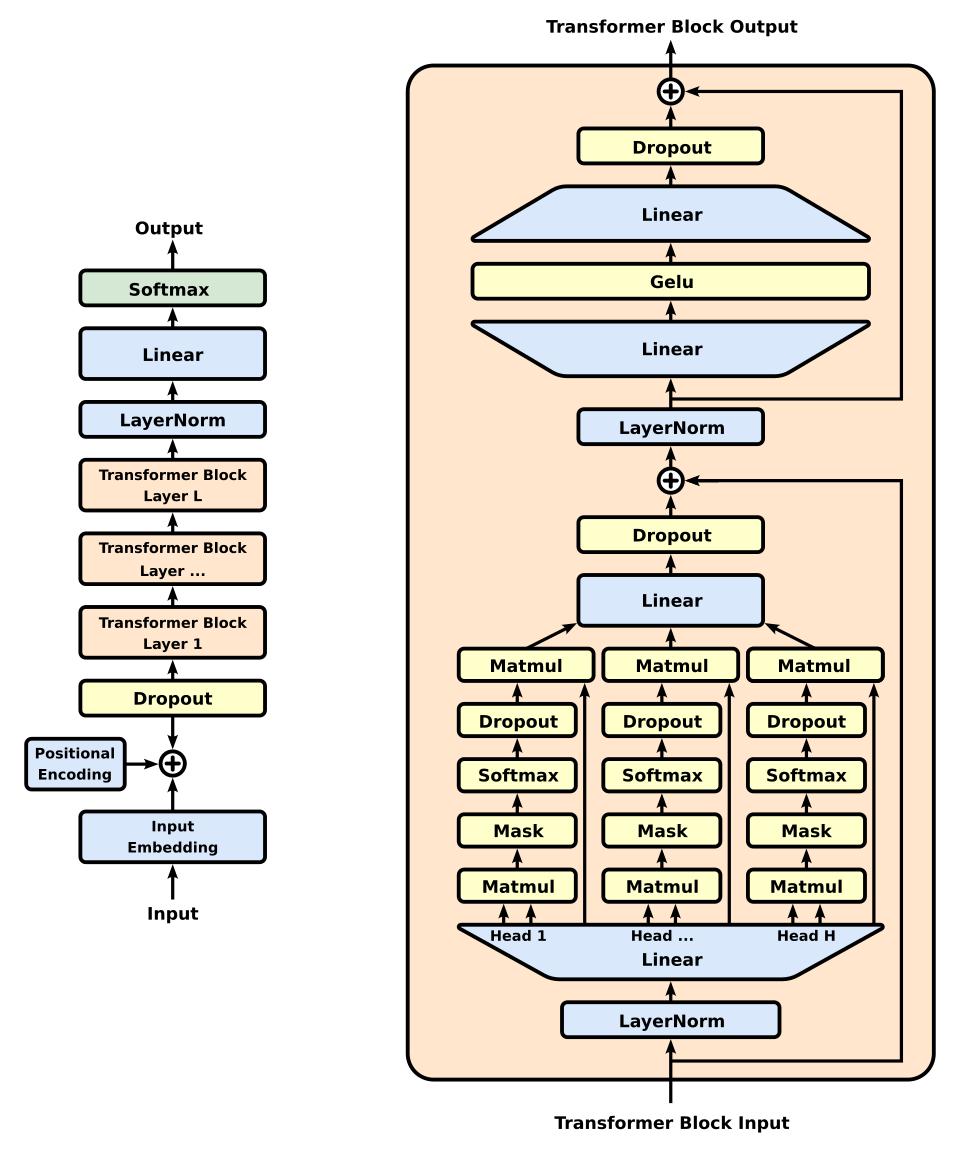

**GPT2**: [Radford A. et al., 2018](https://papers.baulab.info/papers/Radford-2018.pdf), примерно 24,000 цитирований

Модель GPT имеет архитектуру декодера. В данном случае на этапе предобучения рассматривалась задача next token prediction, и соответственно во время обучения используется маскированное само-внимание.

Теперь векторное представление токена можно интерпретировать в том числе, как векторное представление всего левого контекста. Именно оно подается в классификатор, предсказывающий очередной токен. А в качестве векторного представления текста рассматривается векторное контекстуальное представления последнего токена, а не начального, как у BERT.

Заметим также, что на инференсе каждый новый токен предсказывается отдельно по всему прошлому предсказанному контексту, что лишает нас параллелизма (однако, решения данной проблемы существуют, например KV-cache &ndash; см. следующие лекции и курс по [ВВЭфГО](https://github.com/mmp-effml-team/mmp_effml_fall_2025)).

Из преимуществ можно выделить также то, что данные для предобучения не требуют разметки.

Хотя BERT, выйдя после GPT, показал лучшее качество в подавляющем большинстве задач, декодер-модели в будущем все же достигли SOTA на многих бенчмарках. Все дело в ряде преимуществ генеративного подхода:

1. Позволяет решать огромное число самых разных задач, в том числе и задачи классификации. Для этого модели в том числе необходимо уметь генерировать ответ в нужном формате в соответствии с решаемой задачей (предсказываемый класс, JSON, разметка текста итд.).

2. Зачастую не нужно дообучать модель в привычном смысле: few-shot learning (подаем в запросе для модели обучающие примеры без обновления параметров). Для этого подаем на вход предобученной модели инструкции и несколько обучающих примеров. Тем самым, мы не обновляем параметров модели, при этом по входному контексту качество и точность выдаваемых моделью ответов повышается.

3. Можно эффективно дообучать, не имея огромных вычислительных ресурсов под рукой: пример &ndash; LoRA (узнаете совсем скоро).

4. Развитие техник предобучения и дообучения моделей: пример &ndash; применение RL, GRPO итд..

## T5 (2020)

**T5**: [Raffel C. et al., 2020](https://arxiv.org/abs/1910.10683), примерно 31,000 цитирований

Альтернативой BERT и GPT является T5. Он имеет архитектуру близкую к оригинальному трансформеру с энкодером и декодером в составе. Авторы стремились добиться высокого качества в различных Text-to-text задачах. Примеры задач стадии предобучения изображены ниже (иллюстрация из статьи про T5):

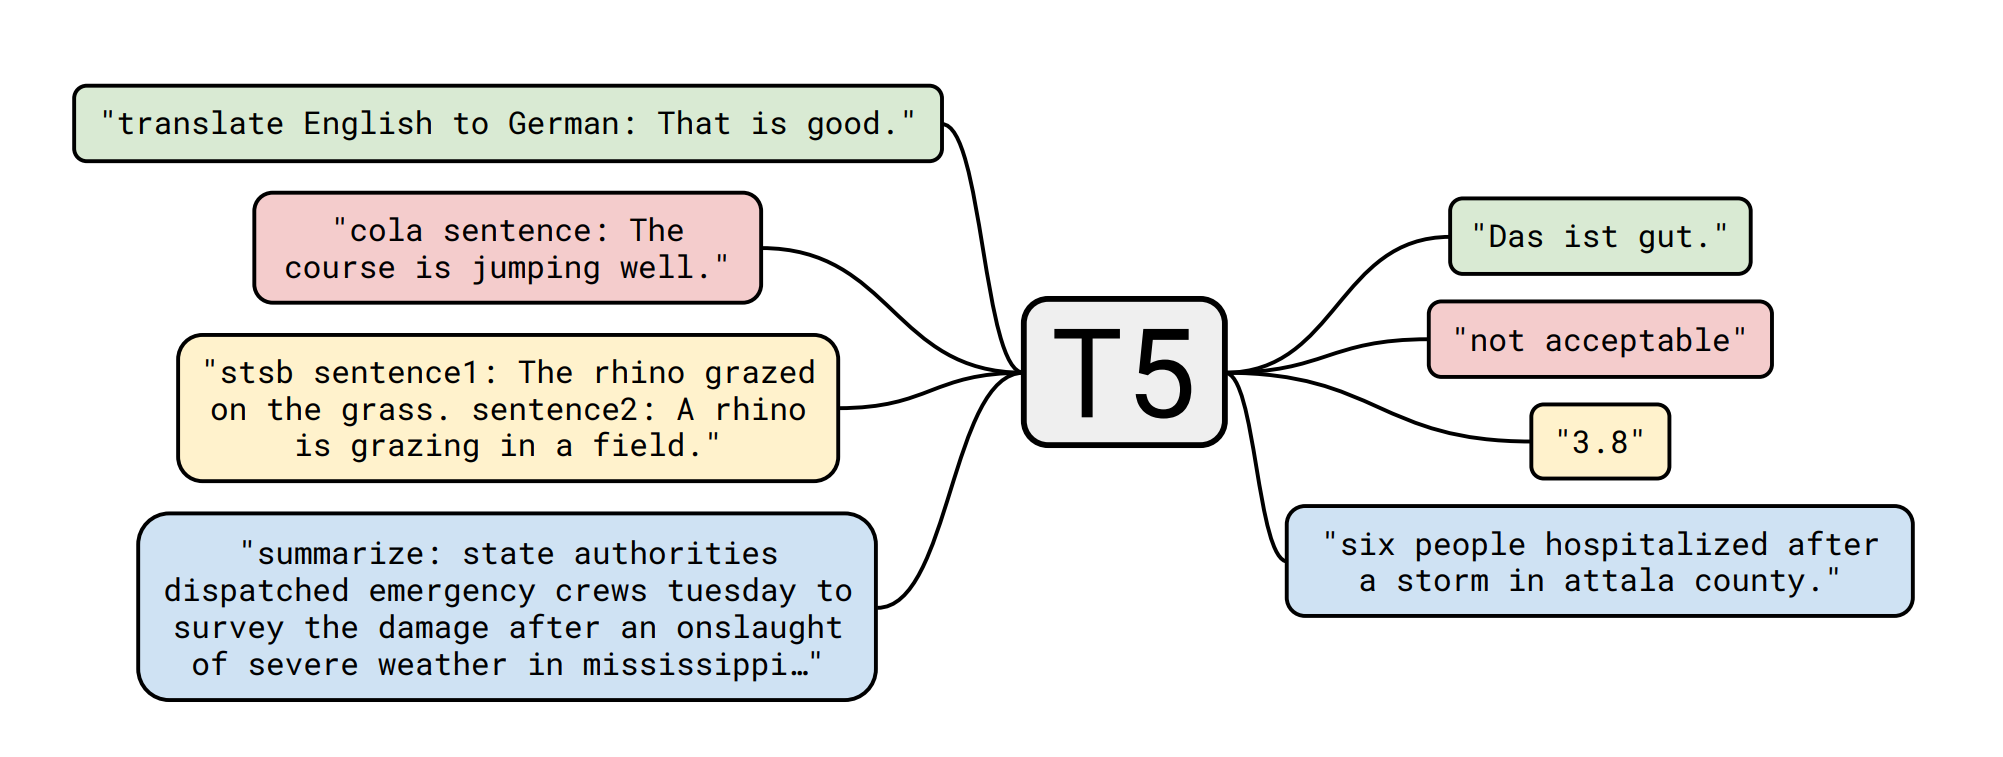

При этом авторы стремились также получить энкодер, который может быть сопоставим по качеству с BERT-подобными моделями. Для этого они предобучали на аналог задания Masked language modeling:

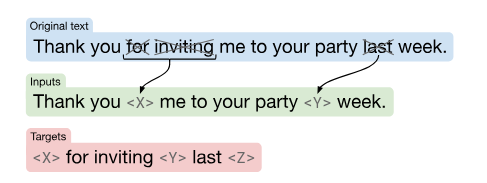

Целью авторов было создание модели, text-to-text формат которой позволяет ей быть успешной в самых разных задачах &ndash; от классификации текстов до суммаризации и перевода. Однако, авторам пришлось использовать огромные объемы размеченных данных. Тем не менее, это позволяет не просто обучаться пониманию языка, но и понимаю конкретных предметных областей и переводам между разными языками.

## Заключение

Сравнивая модели друг с другом, можно сделать вывод о том, что комбинация разных трансформерных архитектур и задач предобучения позволяет применять модели в разных downstream задачах:
1. BERT-подобные модели лучше подходят для выделения векторных представлений всего текста и его элементов, а также для решения более простых задач (например, классификация).
2. GPT-подобные модели лучше подходят для задач, в которых необходима генерация текста (например, генерация решения задачи, сочинения итд.).
3. Модели в духе T5 лучше подходят для text-to-text задач (суммаризация, перевод итд.).